modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!

Sentence: I love learning about Artificial Intelligence.
Embedding shape: (384,)
First 10 values: [ 0.01634455 -0.0765703   0.04107474  0.01962832  0.05804764 -0.05071755
  0.03889348  0.03076576  0.05800403  0.06948569]

Number of sentences: 5
Embedding matrix shape: (5, 384)

Cosine Similarity:


,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00


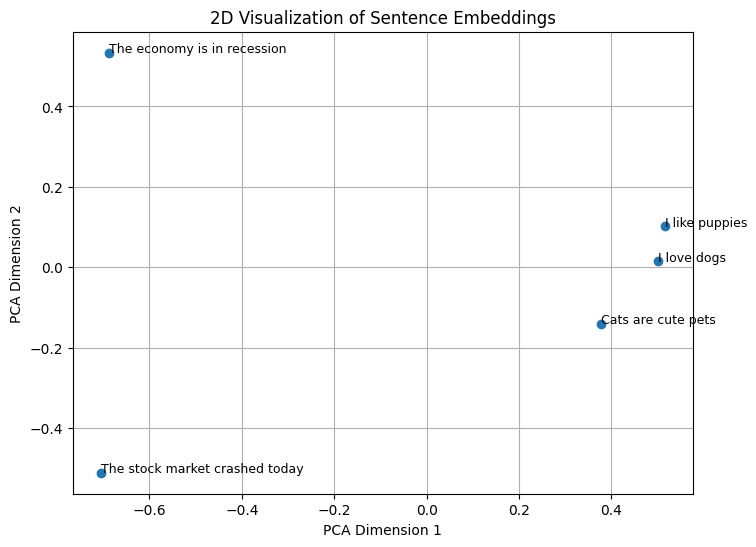


Query: Tell me about AI and neural networks

Score: 0.534 | Deep learning uses neural networks with many layers.
Score: 0.524 | Python is a popular programming language for AI.

Query: What is the capital of France?

Score: 0.824 | Paris is the capital city of France.
Score: 0.102 | Python is a popular programming language for AI.

Query: How does machine learning work?

Score: 0.673 | Machine learning models learn patterns from data.
Score: 0.466 | Deep learning uses neural networks with many layers.

Query: What programming language is useful for artificial intelligence?

Score: 0.778 | Python is a popular programming language for AI.
Score: 0.361 | Deep learning uses neural networks with many layers.


In [2]:
!pip install -q sentence-transformers scikit-learn matplotlib pandas

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")

sentence = "I love learning about Artificial Intelligence."

embedding = model.encode(sentence)

print("\nSentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
]

embeddings = model.encode(sentences)

print("\nNumber of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(
    similarity_matrix,
    index=sentences,
    columns=sentences
)

print("\nCosine Similarity:")
display(df.round(2))

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, sent in enumerate(sentences):
    plt.annotate(
        sent,
        (reduced[i, 0], reduced[i, 1]),
        fontsize=9
    )

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    ranked_idx = scores.argsort()[::-1][:top_k]

    print("\nQuery:", query)
    print()

    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f} | {documents[idx]}")

semantic_search("Tell me about AI and neural networks")

semantic_search("What is the capital of France?")

semantic_search("How does machine learning work?")

semantic_search("What programming language is useful for artificial intelligence?")